### Distribution of crash duration

#### These are the Outliers

Text(0.5, 0, 'Crash Duration (Minutes)')

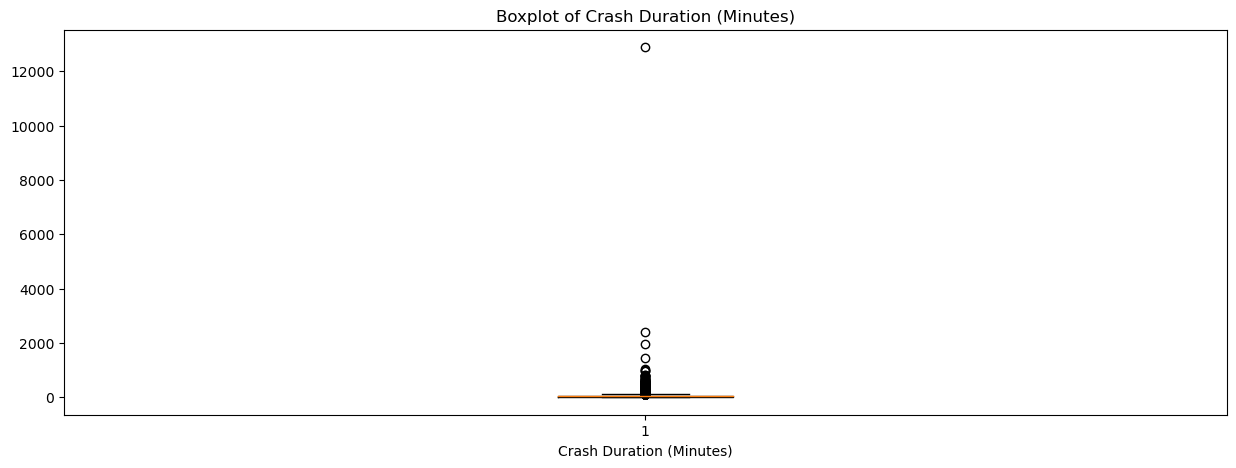

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

crash_info_df = pd.read_csv('./crash_info.csv')

crash_info_df['start_tstamp'] = pd.to_datetime(crash_info_df['start_tstamp'])
crash_info_df['closed_tstamp'] = pd.to_datetime(crash_info_df['closed_tstamp'])

crash_info_df['crash_duration_minutes'] = (crash_info_df['closed_tstamp'] - crash_info_df['start_tstamp']).dt.total_seconds() / 60
crash_info_df['crash_duration_hours'] = crash_info_df['crash_duration_minutes'] / 60

plt.figure(figsize=(15, 5))
plt.boxplot(crash_info_df['crash_duration_minutes'])
plt.title('Boxplot of Crash Duration (Minutes)')
plt.xlabel('Crash Duration (Minutes)')

#### removing outliers

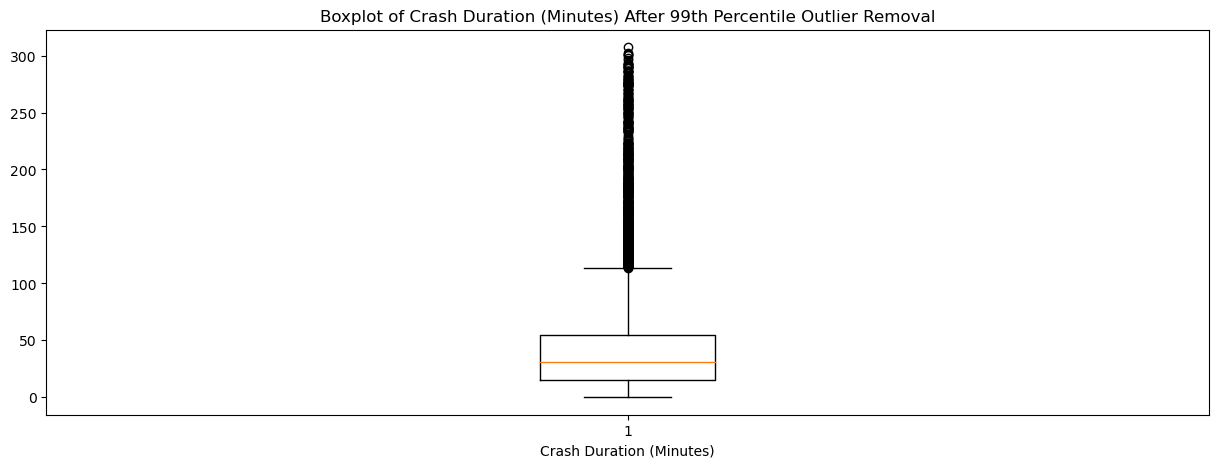

In [2]:
upper_bound = crash_info_df['crash_duration_minutes'].quantile(0.99)

crash_info_df = crash_info_df[crash_info_df['crash_duration_minutes'] <= upper_bound]

import matplotlib.pyplot as plt

plt.figure(figsize=(15, 5))
plt.boxplot(crash_info_df['crash_duration_minutes'])
plt.title('Boxplot of Crash Duration (Minutes) After 99th Percentile Outlier Removal')
plt.xlabel('Crash Duration (Minutes)')
plt.show()

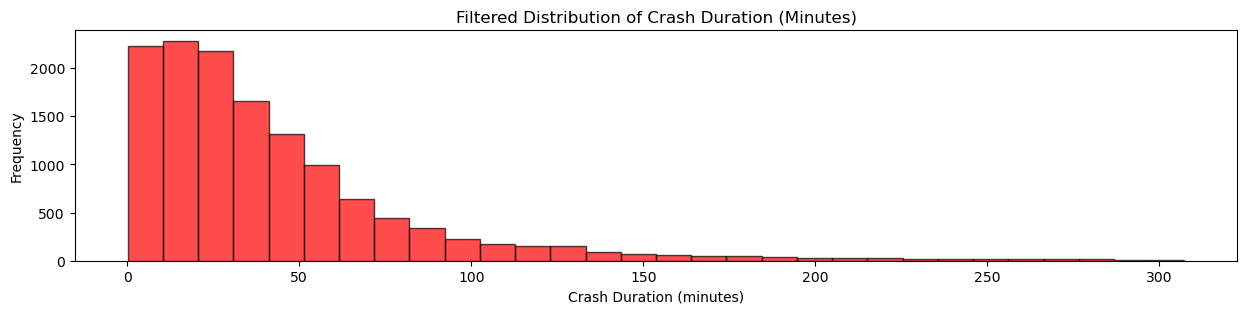

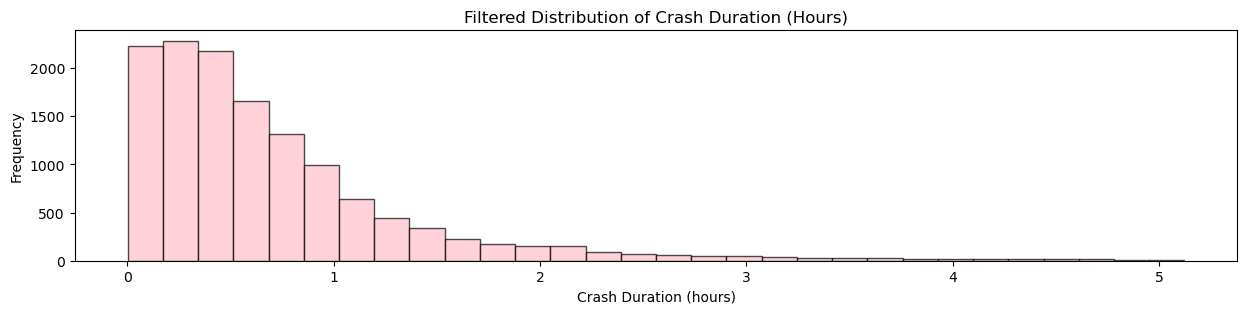

In [3]:
plt.figure(figsize=(15, 3))
plt.hist(crash_info_df['crash_duration_minutes'], bins=30, edgecolor='k', alpha=0.7, color='red')
plt.title('Filtered Distribution of Crash Duration (Minutes)')
plt.xlabel('Crash Duration (minutes)')
plt.ylabel('Frequency')
plt.show()

plt.figure(figsize=(15, 3))
plt.hist(crash_info_df['crash_duration_hours'], bins=30, edgecolor='k', alpha=0.7, color='pink')
plt.title('Filtered Distribution of Crash Duration (Hours)')
plt.xlabel('Crash Duration (hours)')
plt.ylabel('Frequency')
plt.show()

In [4]:
crash_info_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 13361 entries, 0 to 13495
Data columns (total 28 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   event_id                13361 non-null  object 
 1   segment_id              13361 non-null  object 
 2   event_subtype           13361 non-null  object 
 3   start_tstamp            13361 non-null  object 
 4   closed_tstamp           13361 non-null  object 
 5   precipitation_flag      13361 non-null  object 
 6   precip_rate             13352 non-null  float64
 7   speed_at_crash          13175 non-null  float64
 8   reference_speed         13175 non-null  float64
 9   arrived                 12918 non-null  object 
 10  notified                8546 non-null   object 
 11  total_lanes             12773 non-null  float64
 12  open_lanes              12773 non-null  float64
 13  closed_lanes            12773 non-null  float64
 14  unknown_lanes           12773 non-null

In [5]:
time_columns = ['start_tstamp', 'closed_tstamp', 'arrived', 'notified']

existing_time_columns = [col for col in time_columns if col in crash_info_df.columns]

for col in existing_time_columns:
    crash_info_df[col] = pd.to_datetime(crash_info_df[col], errors='coerce', utc=True)

print(crash_info_df.dtypes)

event_id                               object
segment_id                             object
event_subtype                          object
start_tstamp              datetime64[ns, UTC]
closed_tstamp             datetime64[ns, UTC]
precipitation_flag                     object
precip_rate                           float64
speed_at_crash                        float64
reference_speed                       float64
arrived                   datetime64[ns, UTC]
notified                  datetime64[ns, UTC]
total_lanes                           float64
open_lanes                            float64
closed_lanes                          float64
unknown_lanes                         float64
road_condition                         object
vehicle_count                           int64
Car_count                               int64
SUV_count                               int64
Tractor_count                           int64
Bus_count                               int64
Car&Trailor_count                 

In [6]:
crash_info_df

,event_id,segment_id,event_subtype,start_tstamp,closed_tstamp,precipitation_flag,precip_rate,speed_at_crash,reference_speed,arrived,...,SUV_count,Tractor_count,Bus_count,Car&Trailor_count,van_count,overturned,Jack Knifed,Lost_Load,crash_duration_minutes,crash_duration_hours
0,event_0,segment_599,accident,2019-01-01 05:17:09+00:00,2019-01-01 05:51:23+00:00,Rain,0.62,56.0,56.0,2019-01-01 05:17:13+00:00,...,0,0,0,0,0,0,0,0,34.233333,0.570556
1,event_1,segment_853,accident,2019-01-01 05:44:59+00:00,2019-01-01 06:13:24+00:00,No Percipitation,0.00,55.0,56.0,2019-01-01 05:45:07+00:00,...,0,0,0,0,0,0,0,0,28.416667,0.473611
2,event_2,segment_600,accident,2019-01-01 06:01:37+00:00,2019-01-01 06:16:49+00:00,No Percipitation,0.00,57.0,64.0,2019-01-01 06:01:41+00:00,...,0,0,0,0,0,0,0,0,15.200000,0.253333
3,event_3,segment_1209,injury accident,2019-01-01 06:30:04+00:00,2019-01-01 07:35:53+00:00,No Percipitation,0.00,50.0,38.0,2019-01-01 06:32:07+00:00,...,0,0,0,0,0,0,0,0,65.816667,1.096944
4,event_4,segment_2088,accident,2019-01-01 07:20:22+00:00,2019-01-01 07:44:17+00:00,No Percipitation,0.00,43.0,43.0,2019-01-01 07:22:06+00:00,...,0,0,0,0,0,0,0,0,23.916667,0.398611
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13491,event_13491,segment_737,accident,2019-12-31 22:20:29+00:00,2019-12-31 23:33:51+00:00,No Percipitation,0.00,60.0,57.0,2019-12-31 22:21:43+00:00,...,0,0,0,0,0,0,0,0,73.366667,1.222778
13492,event_13492,segment_473,injury accident,2019-12-31 22:47:01+00:00,2019-12-31 23:17:58+00:00,No Percipitation,0.00,67.0,65.0,2019-12-31 22:49:56+00:00,...,0,0,0,0,0,0,0,0,30.950000,0.515833
13493,event_13493,segment_314,accident,2020-01-01 00:13:43+00:00,2020-01-01 00:15:54+00:00,No Percipitation,0.00,NaN,NaN,2020-01-01 00:13:50+00:00,...,0,0,0,0,0,0,0,0,2.183333,0.036389
13494,event_13494,segment_727,accident,2020-01-01 01:14:17+00:00,2020-01-01 02:12:34+00:00,No Percipitation,0.00,NaN,NaN,2020-01-01 01:18:41+00:00,...,0,0,0,0,0,0,0,0,58.283333,0.971389


### Temporal Distribution of crash counts at the hourly, day of the week, and monthly levels. 

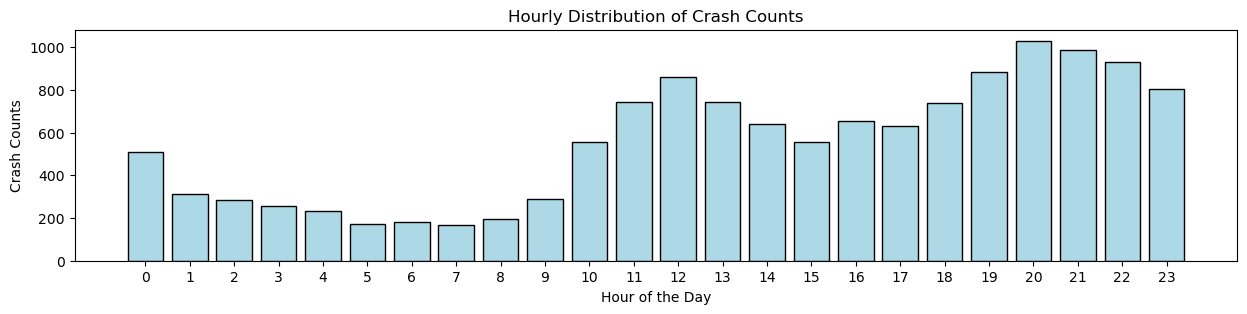

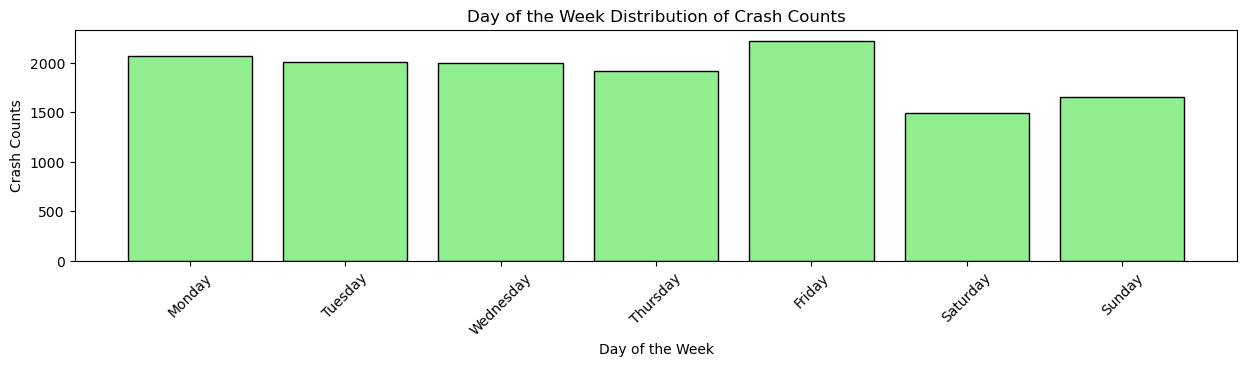

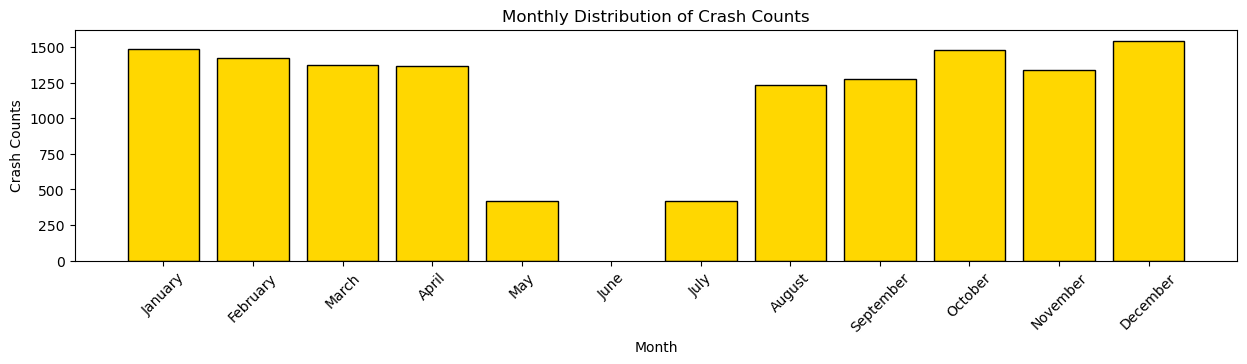

In [7]:
crash_info_df['start_hour'] = crash_info_df['start_tstamp'].dt.hour
crash_info_df['start_day_of_week'] = crash_info_df['start_tstamp'].dt.day_name()  # Day names like 'Monday'
crash_info_df['start_month'] = crash_info_df['start_tstamp'].dt.month_name()     # Month names like 'January'

hourly_counts = crash_info_df['start_hour'].value_counts().sort_index()
weekday_counts = crash_info_df['start_day_of_week'].value_counts().reindex(
    ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
)
monthly_counts = crash_info_df['start_month'].value_counts().reindex([
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December'
])

plt.figure(figsize=(15, 3))
plt.bar(hourly_counts.index, hourly_counts.values, color='#add8e6', edgecolor='black')
plt.title('Hourly Distribution of Crash Counts')
plt.xlabel('Hour of the Day')
plt.ylabel('Crash Counts')
plt.xticks(range(0, 24))

plt.figure(figsize=(15, 3))
plt.bar(weekday_counts.index, weekday_counts.values, color='#90ee90', edgecolor='black')
plt.title('Day of the Week Distribution of Crash Counts')
plt.xlabel('Day of the Week')
plt.ylabel('Crash Counts')
plt.xticks(rotation=45)

plt.figure(figsize=(15, 3))
plt.bar(monthly_counts.index, monthly_counts.values, color='#ffd700', edgecolor='black')
plt.title('Monthly Distribution of Crash Counts')
plt.xlabel('Month')
plt.ylabel('Crash Counts')
plt.xticks(rotation=45)
plt.show()

In [8]:
missing_values = crash_info_df.isnull().sum()
print(missing_values)

event_id                     0
segment_id                   0
event_subtype                0
start_tstamp                 0
closed_tstamp                0
precipitation_flag           0
precip_rate                  9
speed_at_crash             186
reference_speed            186
arrived                    443
notified                  4815
total_lanes                588
open_lanes                 588
closed_lanes               588
unknown_lanes              588
road_condition               0
vehicle_count                0
Car_count                    0
SUV_count                    0
Tractor_count                0
Bus_count                    0
Car&Trailor_count            0
van_count                    0
overturned                   0
Jack Knifed                  0
Lost_Load                    0
crash_duration_minutes       0
crash_duration_hours         0
start_hour                   0
start_day_of_week            0
start_month                  0
dtype: int64


In [10]:
june_crashes = crash_info_df[crash_info_df['start_month'] == 'June']

print(f"Number of crashes in June: {len(june_crashes)}")

Number of crashes in June: 0


### Relationship between crash duration and the total number of vehicles involved in the crash. 

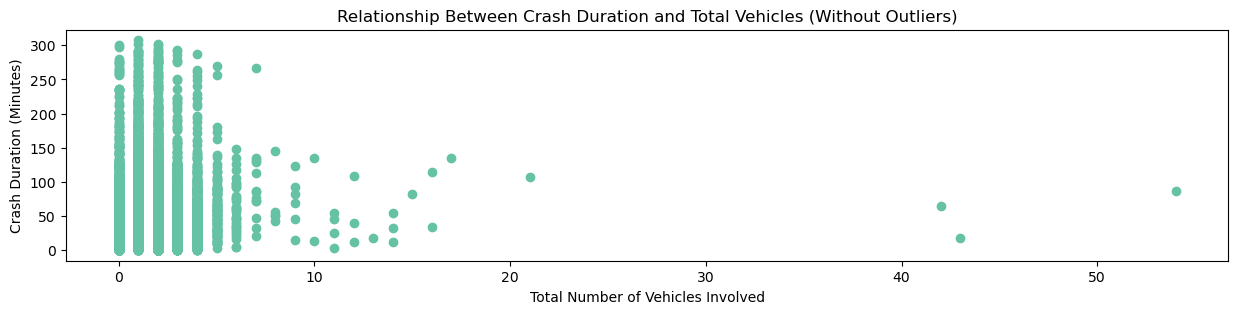

In [11]:
import seaborn as s

plt.figure(figsize=(15, 3))
plt.scatter(crash_info_df['vehicle_count'], crash_info_df['crash_duration_minutes'], color='#66c2a5')
plt.title('Relationship Between Crash Duration and Total Vehicles (Without Outliers)')
plt.xlabel('Total Number of Vehicles Involved')
plt.ylabel('Crash Duration (Minutes)')

plt.show()

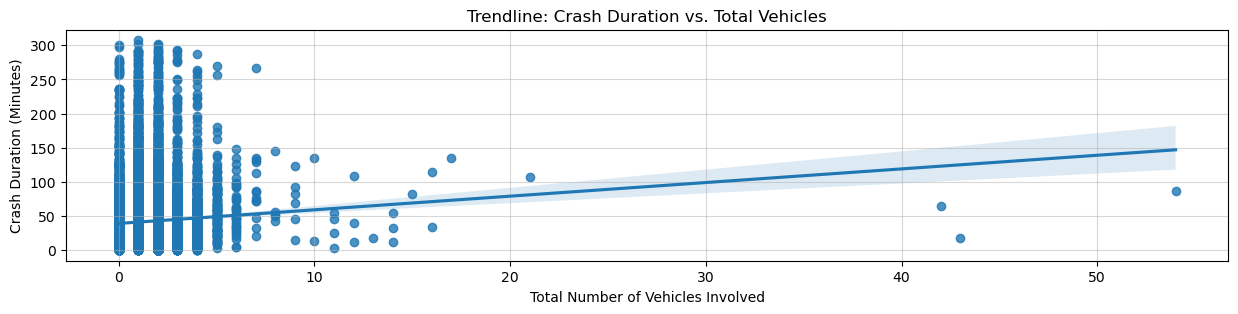

In [12]:
import seaborn as s

plt.figure(figsize=(15, 3))
s.regplot(x='vehicle_count', y='crash_duration_minutes', data=crash_info_df)
plt.title('Trendline: Crash Duration vs. Total Vehicles')
plt.xlabel('Total Number of Vehicles Involved')
plt.ylabel('Crash Duration (Minutes)')
plt.grid(alpha=0.5)
plt.show()

### Visualize the crash count based on the segment functional road class.  

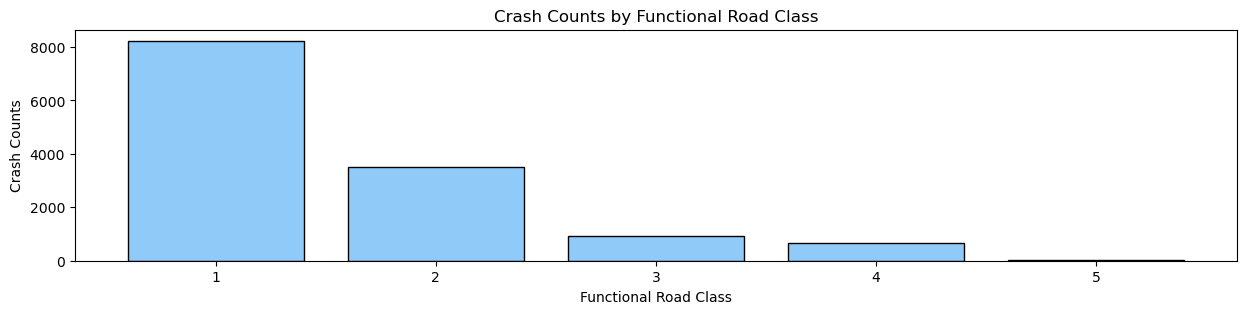

In [13]:
segment_info_df = pd.read_csv('./segment_info.csv')

merged_df = pd.merge(crash_info_df, segment_info_df, left_on='segment_id', right_on='segment_id')

func_class_counts = merged_df['func_class'].value_counts().sort_index()

plt.figure(figsize=(15, 3))
plt.bar(func_class_counts.index, func_class_counts.values, color='#90caf9', edgecolor='black')
plt.title('Crash Counts by Functional Road Class')
plt.xlabel('Functional Road Class')
plt.ylabel('Crash Counts')
plt.show()

### Is there any pattern between the segments' daily VMT (vehicle mile traveled) and their total crash counts? What is the correlation coefficient?

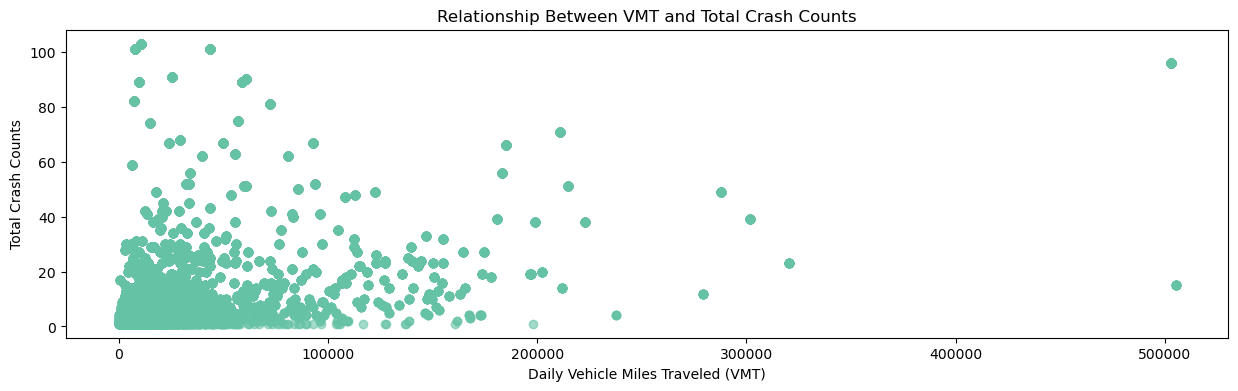

Correlation Coefficient between VMT and Total Crash Counts: 0.27


In [14]:
merged_df['VMT'] = merged_df['aadt'] * merged_df['miles']

crash_counts = merged_df.groupby('segment_id')['event_id'].count().reset_index()
crash_counts.rename(columns={'event_id': 'total_crashes'}, inplace=True)

vmt_crash_df = pd.merge(merged_df[['segment_id', 'VMT']], crash_counts, on='segment_id')

plt.figure(figsize=(15, 4))
plt.scatter(vmt_crash_df['VMT'], vmt_crash_df['total_crashes'], color='#66c2a5', alpha=0.6)
plt.title('Relationship Between VMT and Total Crash Counts')
plt.xlabel('Daily Vehicle Miles Traveled (VMT)')
plt.ylabel('Total Crash Counts')
plt.show()
corr_coeff = vmt_crash_df['VMT'].corr(vmt_crash_df['total_crashes'])
print(f"Correlation Coefficient between VMT and Total Crash Counts: {corr_coeff:.2f}")

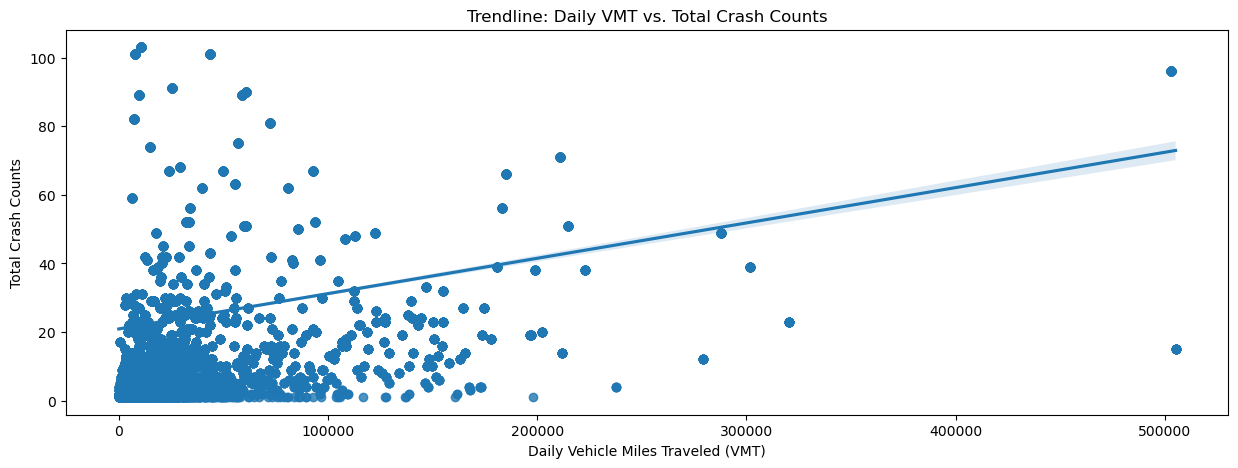

In [15]:
plt.figure(figsize=(15, 5))
s.regplot(x='VMT', y='total_crashes', data=vmt_crash_df)
plt.title('Trendline: Daily VMT vs. Total Crash Counts')
plt.xlabel('Daily Vehicle Miles Traveled (VMT)')
plt.ylabel('Total Crash Counts')
plt.show()

### Develop a linear regression and a Random Forest model to estimate crash duration

#### Preprocessing

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

X = merged_df[['speed_at_crash', 'reference_speed', 'precip_rate', 'vehicle_count',
               'Car_count', 'SUV_count', 'Tractor_count', 'Bus_count', 'Car&Trailor_count',
               'van_count', 'overturned', 'Jack Knifed', 'Lost_Load', 'total_lanes', 'closed_lanes']]
y = merged_df['crash_duration_minutes']

X = X.fillna(0)
y = y.fillna(y.mean())

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [17]:
print(f"Training set size: {len(X_train)} rows")
print(f"Testing set size: {len(X_test)} rows")

Training set size: 9352 rows
Testing set size: 4009 rows


In [18]:
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

y_pred_lr = linear_model.predict(X_test)

mae_lr = mean_absolute_error(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print(f"Linear Regression Performance:")
print(f"Mean Absolute Error: {mae_lr:.2f}")
print(f"Mean Squared Error: {mse_lr:.2f}")
print(f"R² Score: {r2_lr:.2f}")

Linear Regression Performance:
Mean Absolute Error: 27.57
Mean Squared Error: 1840.20
R² Score: 0.05


In [19]:
rf_model_1 = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model_1.fit(X_train, y_train)

y_pred_rf = rf_model_1.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"\nRandom Forest Performance:")
print(f"Mean Absolute Error: {mae_rf:.2f}")
print(f"Mean Squared Error: {mse_rf:.2f}")
print(f"R² Score: {r2_rf:.2f}")


Random Forest Performance:
Mean Absolute Error: 27.94
Mean Squared Error: 1703.51
R² Score: 0.12


the results were quite low so I checked the correlation

In [20]:
# Select the features and target variable
selected_features = merged_df[['speed_at_crash', 'reference_speed', 'precip_rate', 'vehicle_count',
                               'Car_count', 'SUV_count', 'Tractor_count', 'Bus_count', 'Car&Trailor_count',
                               'van_count', 'overturned', 'Jack Knifed', 'Lost_Load', 'total_lanes', 'closed_lanes']]
target = merged_df['crash_duration_minutes']

correlation = selected_features.corrwith(target)
print(correlation)

speed_at_crash       0.070127
reference_speed     -0.068638
precip_rate          0.007976
vehicle_count        0.064133
Car_count           -0.001375
SUV_count            0.119652
Tractor_count        0.030715
Bus_count            0.052215
Car&Trailor_count    0.124527
van_count            0.021750
overturned           0.200033
Jack Knifed          0.054370
Lost_Load            0.074952
total_lanes         -0.152093
closed_lanes         0.194446
dtype: float64


changed the ones that were having less correlation

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

X = merged_df[['Car&Trailor_count', 'SUV_count', 'overturned','total_lanes', 'closed_lanes']]
y = merged_df['crash_duration_minutes']

X = X.fillna(0)
y = y.fillna(y.mean())

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [22]:
linear_model_2 = LinearRegression()
linear_model_2.fit(X_train, y_train)
y_pred_lr = linear_model_2.predict(X_test)

mae_lr = mean_absolute_error(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression Performance:")
print(f"Mean Absolute Error: {mae_lr:.2f}")
print(f"Mean Squared Error: {mse_lr:.2f}")
print(f"R² Score: {r2_lr:.2f}")

Linear Regression Performance:
Mean Absolute Error: 28.04
Mean Squared Error: 1731.58
R² Score: 0.10


In [23]:
rf_model_2 = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model_2.fit(X_train, y_train)

y_pred_rf = rf_model_2.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"\nRandom Forest Performance:")
print(f"Mean Absolute Error: {mae_rf:.2f}")
print(f"Mean Squared Error: {mse_rf:.2f}")
print(f"R² Score: {r2_rf:.2f}")


Random Forest Performance:
Mean Absolute Error: 27.40
Mean Squared Error: 1658.70
R² Score: 0.14


it was still low, so i wanted to do hyperparameter tuning

In [24]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

rf = RandomForestRegressor(random_state=42)

grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=3, n_jobs=-1, verbose=2)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best Score:", grid_search.best_score_)

Fitting 3 folds for each of 36 candidates, totalling 108 fits
Best Parameters: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}
Best Score: 0.12300253209707386


In [25]:
rf_model_3 = grid_search.best_estimator_

y_pred_rf = rf_model_3.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Tuned Random Forest Performance:")
print(f"Mean Absolute Error: {mae_rf:.2f}")
print(f"Mean Squared Error: {mse_rf:.2f}")
print(f"R² Score: {r2_rf:.2f}")

Tuned Random Forest Performance:
Mean Absolute Error: 27.18
Mean Squared Error: 1619.45
R² Score: 0.16


there was no significant change still, so checked out the categorical variables, I wanted to know if the variablity in target variable could be explained by the non linear variables

In [26]:
categorical_cols = merged_df.select_dtypes(include=['object']).columns

for col in categorical_cols:
    print(f"{col}: {merged_df[col].unique()}")

event_id: ['event_0' 'event_474' 'event_1367' ... 'event_13467' 'event_13483'
 'event_13484']
segment_id: ['segment_599' 'segment_853' 'segment_600' ... 'segment_1636'
 'segment_1956' 'segment_1469']
event_subtype: ['accident' 'injury accident' 'serious accident']
precipitation_flag: ['Rain' 'No Percipitation' 'Snow']
road_condition: ['Wet' 'Dry' 'Wet - chemicals' 'Ice/Snow' 'Unspecified']
start_day_of_week: ['Tuesday' 'Friday' 'Monday' 'Wednesday' 'Thursday' 'Sunday' 'Saturday']
start_month: ['January' 'February' 'March' 'July' 'October' 'December' 'April' 'May'
 'August' 'September' 'November']
road: ['road_11000102' 'road_11000110' 'road_11000172' 'road_11053941'
 'road_11000092' 'road_11000105' 'road_11000103' 'road_11000986'
 'road_11000089' 'road_11000100' 'road_11000070' 'road_11001639'
 'road_11000073' 'road_11000081' 'road_11000115' 'road_11000097'
 'road_11000066' 'road_11000880' 'road_11000091' 'road_11001020'
 'road_11000106' 'road_11000211' 'road_11000154' 'road_11000902'


did one hot encoding as they were non-linear variables

In [27]:
categorical_cols = ['event_subtype', 'precipitation_flag', 'road_condition', 
                    'start_day_of_week', 'start_month', 'direction', 'road_class', 'func_class']

merged_df_encoded = pd.get_dummies(merged_df, columns=categorical_cols, drop_first=False)

merged_df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 13361 entries, 0 to 13360
Data columns (total 83 columns):
 #   Column                                                               Non-Null Count  Dtype              
---  ------                                                               --------------  -----              
 0   event_id                                                             13361 non-null  object             
 1   segment_id                                                           13361 non-null  object             
 2   start_tstamp                                                         13361 non-null  datetime64[ns, UTC]
 3   closed_tstamp                                                        13361 non-null  datetime64[ns, UTC]
 4   precip_rate                                                          13352 non-null  float64            
 5   speed_at_crash                                                       13175 non-null  float64            
 6   refere

The missing values in the dataset are imputed with the mean for continuous columns (`precip_rate`, `speed_at_crash`, `reference_speed`) and the mode for categorical columns (`arrived`, `notified`, `total_lanes`, `open_lanes`, `closed_lanes`, `unknown_lanes`).


In [28]:
na_counts = merged_df_encoded.isnull().sum()
print("Missing values in each column:")
print(na_counts[na_counts > 0])

Missing values in each column:
precip_rate           9
speed_at_crash      186
reference_speed     186
arrived             443
notified           4815
total_lanes         588
open_lanes          588
closed_lanes        588
unknown_lanes       588
dtype: int64


In [29]:
merged_df_encoded['precip_rate'].fillna(merged_df_encoded['precip_rate'].mean(), inplace=True)
merged_df_encoded['speed_at_crash'].fillna(merged_df_encoded['speed_at_crash'].mean(), inplace=True)
merged_df_encoded['reference_speed'].fillna(merged_df_encoded['reference_speed'].mean(), inplace=True)

merged_df_encoded['arrived'].fillna(merged_df_encoded['arrived'].mode()[0], inplace=True)
merged_df_encoded['notified'].fillna(merged_df_encoded['notified'].mode()[0], inplace=True)

merged_df_encoded['total_lanes'].fillna(merged_df_encoded['total_lanes'].mode()[0], inplace=True)
merged_df_encoded['open_lanes'].fillna(merged_df_encoded['open_lanes'].mode()[0], inplace=True)
merged_df_encoded['closed_lanes'].fillna(merged_df_encoded['closed_lanes'].mode()[0], inplace=True)
merged_df_encoded['unknown_lanes'].fillna(merged_df_encoded['unknown_lanes'].mode()[0], inplace=True)

print("Missing values after imputation:")
print(merged_df_encoded.isnull().sum().sum())

Missing values after imputation:
0


In [30]:
X = merged_df_encoded.drop(columns=['event_id', 'segment_id', 'road', 'start_tstamp', 'closed_tstamp', 'arrived', 'notified','crash_duration_hours', 'crash_duration_minutes'])
y = merged_df_encoded['crash_duration_minutes']

The correlation between features and the target variable is computed, and features with an absolute correlation above a threshold of 0.1 are selected for further analysis.


In [31]:
correlation = X.corrwith(y)

correlation_sorted = correlation.sort_values(ascending=False)
print(correlation_sorted)

event_subtype_serious accident    0.346187
closed_lanes                      0.200318
overturned                        0.200033
event_subtype_injury accident     0.190414
road_class_State Route            0.144867
                                    ...   
road_class_Interstate            -0.115248
total_lanes                      -0.151822
aadt                             -0.182976
open_lanes                       -0.185199
event_subtype_accident           -0.269346
Length: 74, dtype: float64


In [32]:
correlation = X.corrwith(y)

threshold = 0.1

highly_correlated = correlation[correlation.abs() > threshold].sort_values(ascending=False)

print(highly_correlated)

X = X[highly_correlated.index]

event_subtype_serious accident    0.346187
closed_lanes                      0.200318
overturned                        0.200033
event_subtype_injury accident     0.190414
road_class_State Route            0.144867
Car&Trailor_count                 0.124527
SUV_count                         0.119652
func_class_3                      0.119327
miles                             0.117511
func_class_4                      0.112504
start_hour                       -0.109533
road_class_Interstate            -0.115248
total_lanes                      -0.151822
aadt                             -0.182976
open_lanes                       -0.185199
event_subtype_accident           -0.269346
dtype: float64


Variance Inflation Factor (VIF) is calculated to detect multicollinearity, and features with high VIF values (`event_subtype_accident`, `total_lanes`) are iteratively dropped to reduce multicollinearity in the dataset.


In [33]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame()
vif_data['feature'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(vif_data)

                           feature        VIF
0   event_subtype_serious accident   1.427035
1                     closed_lanes   1.210585
2                       overturned   1.038219
3    event_subtype_injury accident   7.789472
4           road_class_State Route   2.130194
5                Car&Trailor_count   1.106363
6                        SUV_count   1.009519
7                     func_class_3   1.444221
8                            miles   1.070397
9                     func_class_4   1.454637
10                      start_hour   1.015423
11           road_class_Interstate   2.036061
12                     total_lanes   2.803058
13                            aadt   1.513058
14                      open_lanes   2.800365
15          event_subtype_accident  22.949357


In [34]:
X = X.drop('event_subtype_accident', axis=1)

vif_data = pd.DataFrame()
vif_data['feature'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(vif_data)

                           feature        VIF
0   event_subtype_serious accident   1.162940
1                     closed_lanes   1.710130
2                       overturned   1.076608
3    event_subtype_injury accident   1.395503
4           road_class_State Route   2.205310
5                Car&Trailor_count   1.111947
6                        SUV_count   1.170018
7                     func_class_3   1.526981
8                            miles   1.706584
9                     func_class_4   1.479611
10                      start_hour   4.700432
11           road_class_Interstate   6.895146
12                     total_lanes  25.207308
13                            aadt   6.001461
14                      open_lanes  15.498046


In [35]:
X = X.drop('total_lanes', axis=1)

vif_data = pd.DataFrame()
vif_data['feature'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(vif_data)

                           feature       VIF
0   event_subtype_serious accident  1.152440
1                     closed_lanes  1.652017
2                       overturned  1.073283
3    event_subtype_injury accident  1.368216
4           road_class_State Route  2.138606
5                Car&Trailor_count  1.109931
6                        SUV_count  1.169453
7                     func_class_3  1.509301
8                            miles  1.705402
9                     func_class_4  1.456617
10                      start_hour  4.379082
11           road_class_Interstate  6.240221
12                            aadt  5.553434
13                      open_lanes  6.320537


did linear regression and random forest regressor again with the new features

In [36]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [37]:
linear_model_3 = LinearRegression()
linear_model_3.fit(X_train, y_train)
y_pred_lr = linear_model_3.predict(X_test)

mae_lr = mean_absolute_error(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression Performance:")
print(f"Mean Absolute Error: {mae_lr:.2f}")
print(f"Mean Squared Error: {mse_lr:.2f}")
print(f"R² Score: {r2_lr:.2f}")

Linear Regression Performance:
Mean Absolute Error: 25.87
Mean Squared Error: 1437.54
R² Score: 0.27


In [38]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None],           
    'min_samples_split': [2, 5, 10],       
    'min_samples_leaf': [1, 2, 4]          
}

rf = RandomForestRegressor(random_state=42)

grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=3, n_jobs=-1, verbose=2)

grid_search.fit(X_train, y_train)

print("\nBest Parameters:", grid_search.best_params_)
print("Best Score:", grid_search.best_score_)

Fitting 3 folds for each of 81 candidates, totalling 243 fits

Best Parameters: {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 300}
Best Score: 0.25820501793924666


In [39]:
rf_model_4 = grid_search.best_estimator_
y_pred_best_rf = rf_model_4.predict(X_test)

mae_best_rf = mean_absolute_error(y_test, y_pred_best_rf)
mse_best_rf = mean_squared_error(y_test, y_pred_best_rf)
r2_best_rf = r2_score(y_test, y_pred_best_rf)

print("\nTuned Random Forest Performance:")
print(f"Mean Absolute Error: {mae_best_rf:.2f}")
print(f"Mean Squared Error: {mse_best_rf:.2f}")
print(f"R² Score: {r2_best_rf:.2f}")


Tuned Random Forest Performance:
Mean Absolute Error: 25.42
Mean Squared Error: 1411.86
R² Score: 0.28


we could see that the R^2 values changed drastically from ~0.05 / ~0.16 to 0.27/0.28

from here I wanted to try out Gradient Boosting Regressor (GBR) with proper Hyper-parameter tuning

In [40]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 10],
    'learning_rate': [0.01, 0.1, 0.2],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

gbr = GradientBoostingRegressor(random_state=42)

grid_search_gbr = GridSearchCV(estimator=gbr, param_grid=param_grid, cv=3, n_jobs=-1, verbose=2)

grid_search_gbr.fit(X_train, y_train)

print("\nBest Parameters:", grid_search_gbr.best_params_)
print("Best Score:", grid_search_gbr.best_score_)

best_gbr_model = grid_search_gbr.best_estimator_

y_pred_best_gbr = best_gbr_model.predict(X_test)

mae_best_gbr = mean_absolute_error(y_test, y_pred_best_gbr)
mse_best_gbr = mean_squared_error(y_test, y_pred_best_gbr)
r2_best_gbr = r2_score(y_test, y_pred_best_gbr)

print("\nTuned Gradient Boosting Regressor Performance:")
print(f"Mean Absolute Error: {mae_best_gbr:.2f}")
print(f"Mean Squared Error: {mse_best_gbr:.2f}")
print(f"R² Score: {r2_best_gbr:.2f}")

Fitting 3 folds for each of 243 candidates, totalling 729 fits

Best Parameters: {'learning_rate': 0.1, 'max_depth': 3, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 100}
Best Score: 0.26743319859673176

Tuned Gradient Boosting Regressor Performance:
Mean Absolute Error: 25.25
Mean Squared Error: 1382.37
R² Score: 0.30


Hmm.. I Could only see a small change here, I am now switching to XGBoost because it is a powerful gradient boosting model that often perform better on structured/tabular data like here.

In [41]:
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [42]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'min_child_weight': [1, 3, 5],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'gamma': [0, 0.1],
    'reg_alpha': [0, 0.1],
    'reg_lambda': [1, 2]
}


xgb = XGBRegressor(random_state=42)

grid_search_xgb = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    cv=3,
    n_jobs=-1,
    verbose=2
)

grid_search_xgb.fit(X_train, y_train)

print("Best Parameters:", grid_search_xgb.best_params_)
print("Best Score:", grid_search_xgb.best_score_)

best_xgb_model = grid_search_xgb.best_estimator_

y_pred_best_xgb = best_xgb_model.predict(X_test)

mae_xgb = mean_absolute_error(y_test, y_pred_best_xgb)
mse_xgb = mean_squared_error(y_test, y_pred_best_xgb)
r2_xgb = r2_score(y_test, y_pred_best_xgb)

print("\nTuned XGBoost Regressor Performance:")
print(f"Mean Absolute Error: {mae_xgb:.2f}")
print(f"Mean Squared Error: {mse_xgb:.2f}")
print(f"R² Score: {r2_xgb:.2f}")

Fitting 3 folds for each of 2592 candidates, totalling 7776 fits
Best Parameters: {'colsample_bytree': 0.8, 'gamma': 0, 'learning_rate': 0.1, 'max_depth': 3, 'min_child_weight': 5, 'n_estimators': 100, 'reg_alpha': 0.1, 'reg_lambda': 2, 'subsample': 0.8}
Best Score: 0.2710992080105487

Tuned XGBoost Regressor Performance:
Mean Absolute Error: 25.13
Mean Squared Error: 1370.75
R² Score: 0.30


<Figure size 1000x800 with 0 Axes>

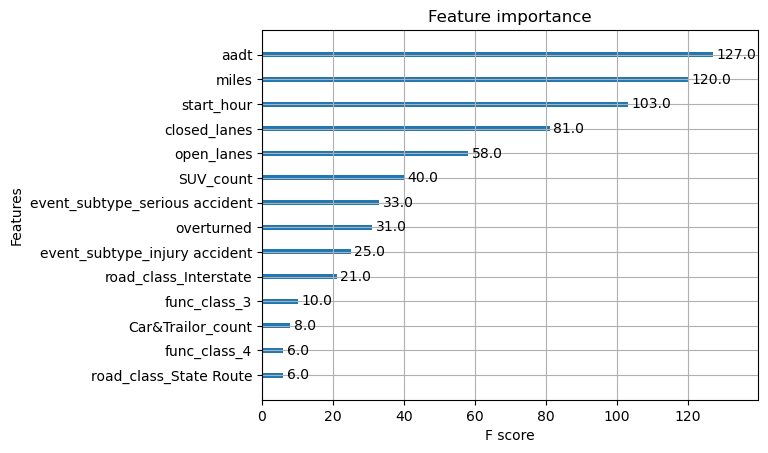

In [43]:
import matplotlib.pyplot as plt
from xgboost import plot_importance

plt.figure(figsize=(10, 8))
plot_importance(best_xgb_model)
plt.show()

lets see how well each model performed using a residual plot

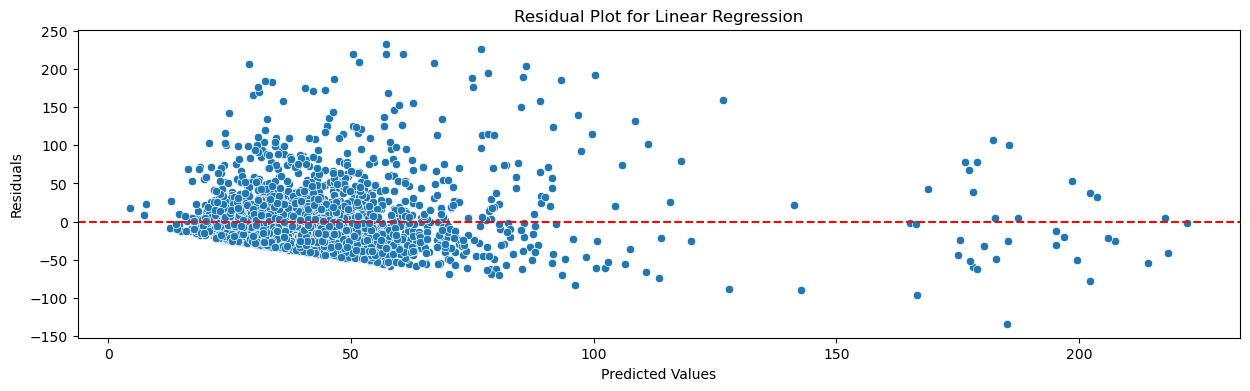

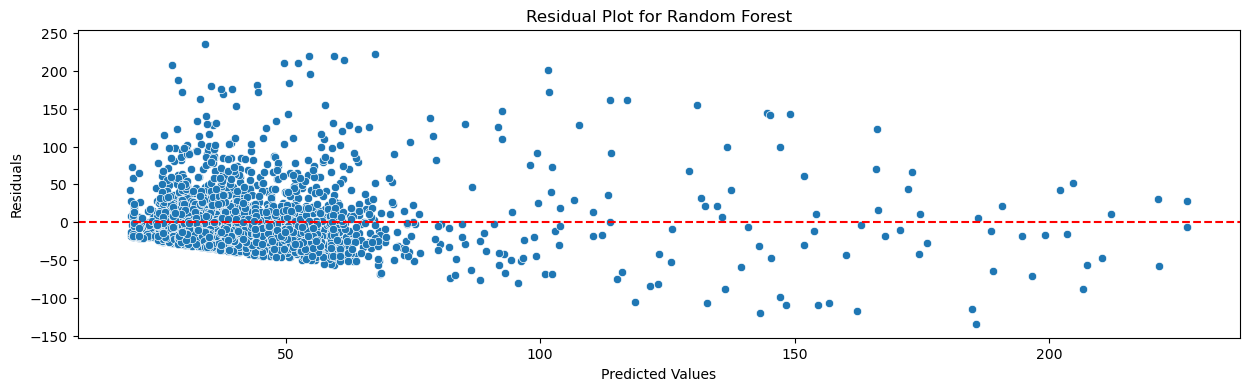

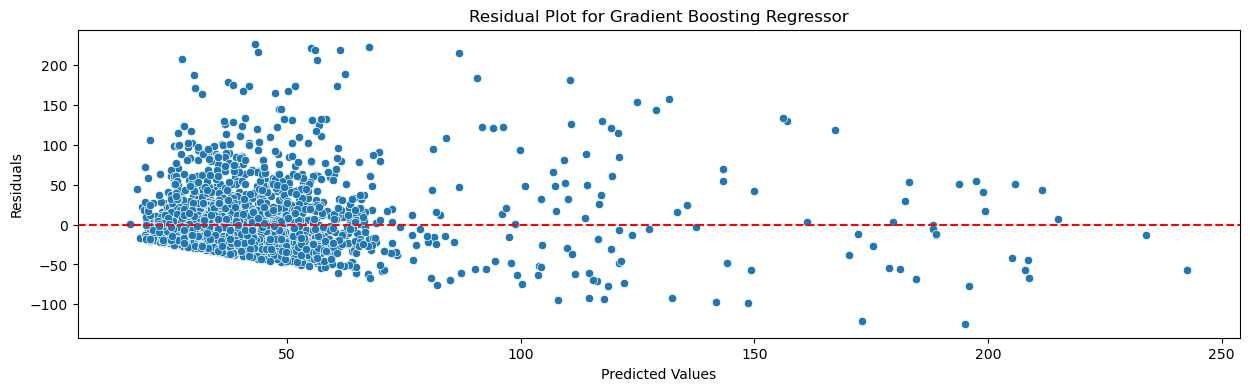

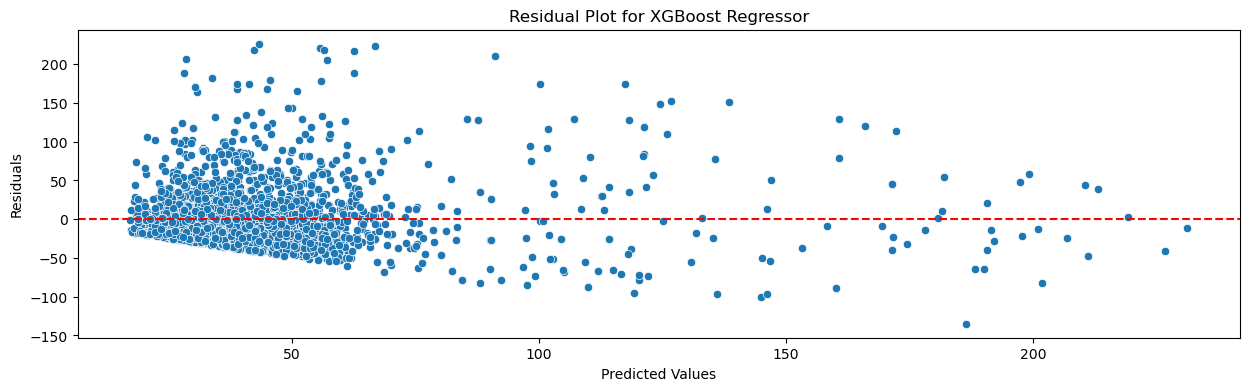

In [44]:
def plot_residuals(y_test, y_pred, model_name):
    residuals = y_test - y_pred
    plt.figure(figsize=(15, 4))
    s.scatterplot(x=y_pred, y=residuals)
    plt.axhline(y=0, color='r', linestyle='--')
    plt.title(f'Residual Plot for {model_name}')
    plt.xlabel('Predicted Values')
    plt.ylabel('Residuals')
    plt.show()

plot_residuals(y_test, y_pred_lr, 'Linear Regression')
plot_residuals(y_test, y_pred_best_rf, 'Random Forest')
plot_residuals(y_test, y_pred_best_gbr, 'Gradient Boosting Regressor')
plot_residuals(y_test, y_pred_best_xgb, 'XGBoost Regressor')

### For the segments with higher than 75 crashes per year, show the speed ratio distribution for non-crash time intervals vs. crash time intervals.  

In [377]:
import pandas as pd

speed = pd.read_csv('speed.csv', parse_dates=['measurement_tstamp'])

print(speed.info())
print(speed.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3253288 entries, 0 to 3253287
Data columns (total 3 columns):
 #   Column              Dtype  
---  ------              -----  
 0   segment_id          object 
 1   measurement_tstamp  object 
 2   speed               float64
dtypes: float64(1), object(2)
memory usage: 74.5+ MB
None
    segment_id         measurement_tstamp  speed
0  segment_879  2019-01-01 00:00:00-05:00   57.2
1  segment_879  2019-01-01 00:05:00-05:00   56.4
2  segment_879  2019-01-01 00:10:00-05:00   56.6
3  segment_879  2019-01-01 00:15:00-05:00   57.0
4  segment_879  2019-01-01 00:20:00-05:00   57.0


In [378]:
speed['measurement_tstamp'] = pd.to_datetime(speed['measurement_tstamp'],errors='coerce', utc=True)

print(speed.info())
print(speed.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3253288 entries, 0 to 3253287
Data columns (total 3 columns):
 #   Column              Dtype              
---  ------              -----              
 0   segment_id          object             
 1   measurement_tstamp  datetime64[ns, UTC]
 2   speed               float64            
dtypes: datetime64[ns, UTC](1), float64(1), object(1)
memory usage: 74.5+ MB
None
    segment_id        measurement_tstamp  speed
0  segment_879 2019-01-01 05:00:00+00:00   57.2
1  segment_879 2019-01-01 05:05:00+00:00   56.4
2  segment_879 2019-01-01 05:10:00+00:00   56.6
3  segment_879 2019-01-01 05:15:00+00:00   57.0
4  segment_879 2019-01-01 05:20:00+00:00   57.0


In [379]:
merged_df['start_year'] = merged_df['start_tstamp'].dt.year
crashes_per_segment = (
    merged_df.groupby(['segment_id', 'start_year'])['event_id']
    .nunique()
    .reset_index(name='crash_count')
)

In [380]:
high_crash_segments = crashes_per_segment[crashes_per_segment['crash_count'] > 75]['segment_id'].unique()

print(f"Number of segments with more than 75 crashes in a year: {len(high_crash_segments)}")

Number of segments with more than 75 crashes in a year: 10


In [381]:
high_crash_segments

array(['segment_2034', 'segment_2037', 'segment_2091', 'segment_408',
       'segment_434', 'segment_440', 'segment_473', 'segment_503',
       'segment_963', 'segment_987'], dtype=object)

In [382]:
high_crash_events = merged_df[merged_df['segment_id'].isin(high_crash_segments)]
high_crash_speeds = speed[speed['segment_id'].isin(high_crash_segments)].copy()

In [383]:
high_crash_speeds.head()

,segment_id,measurement_tstamp,speed
288,segment_440,2019-01-01 05:00:00+00:00,61.99
289,segment_440,2019-01-01 05:05:00+00:00,62.20
290,segment_440,2019-01-01 05:10:00+00:00,58.11
291,segment_440,2019-01-01 05:15:00+00:00,58.76
292,segment_440,2019-01-01 05:20:00+00:00,60.78


In [384]:
high_crash_events = high_crash_events.copy()

high_crash_speeds['is_crash'] = False

high_crash_events['start_tstamp'] = high_crash_events['start_tstamp'].dt.floor('5T')
high_crash_events['closed_tstamp'] = high_crash_events['closed_tstamp'].dt.floor('5T')

for _, crash in high_crash_events.iterrows():
    crash_start = crash['start_tstamp']
    crash_end = crash['closed_tstamp']
    segment = crash['segment_id']

    high_crash_speeds.loc[
        (high_crash_speeds['segment_id'] == segment) &
        (high_crash_speeds['measurement_tstamp'] >= crash_start) &
        (high_crash_speeds['measurement_tstamp'] <= crash_end),
        'is_crash'
    ] = True


In [385]:
high_crash_speeds[high_crash_speeds['is_crash'] == True]

,segment_id,measurement_tstamp,speed,is_crash
7933,segment_987,2019-01-01 18:05:00+00:00,65.00,True
7934,segment_987,2019-01-01 18:10:00+00:00,64.18,True
7935,segment_987,2019-01-01 18:15:00+00:00,63.00,True
7936,segment_987,2019-01-01 18:20:00+00:00,56.00,True
7937,segment_987,2019-01-01 18:25:00+00:00,53.60,True
...,...,...,...,...
3246879,segment_473,2019-12-31 22:55:00+00:00,67.60,True
3246880,segment_473,2019-12-31 23:00:00+00:00,67.20,True
3246881,segment_473,2019-12-31 23:05:00+00:00,68.00,True
3246882,segment_473,2019-12-31 23:10:00+00:00,68.00,True


In [386]:
high_crash_speeds = pd.merge(
    high_crash_speeds,
    high_crash_events[['segment_id', 'reference_speed']].drop_duplicates(),
    on='segment_id',
    how='left'
)

In [387]:
high_crash_speeds['reference_speed'] = high_crash_speeds.groupby('segment_id')['reference_speed'].transform(lambda x: x.fillna(x.mean()))

In [388]:
high_crash_speeds['speed_ratio'] = high_crash_speeds['speed'] / high_crash_speeds['reference_speed']

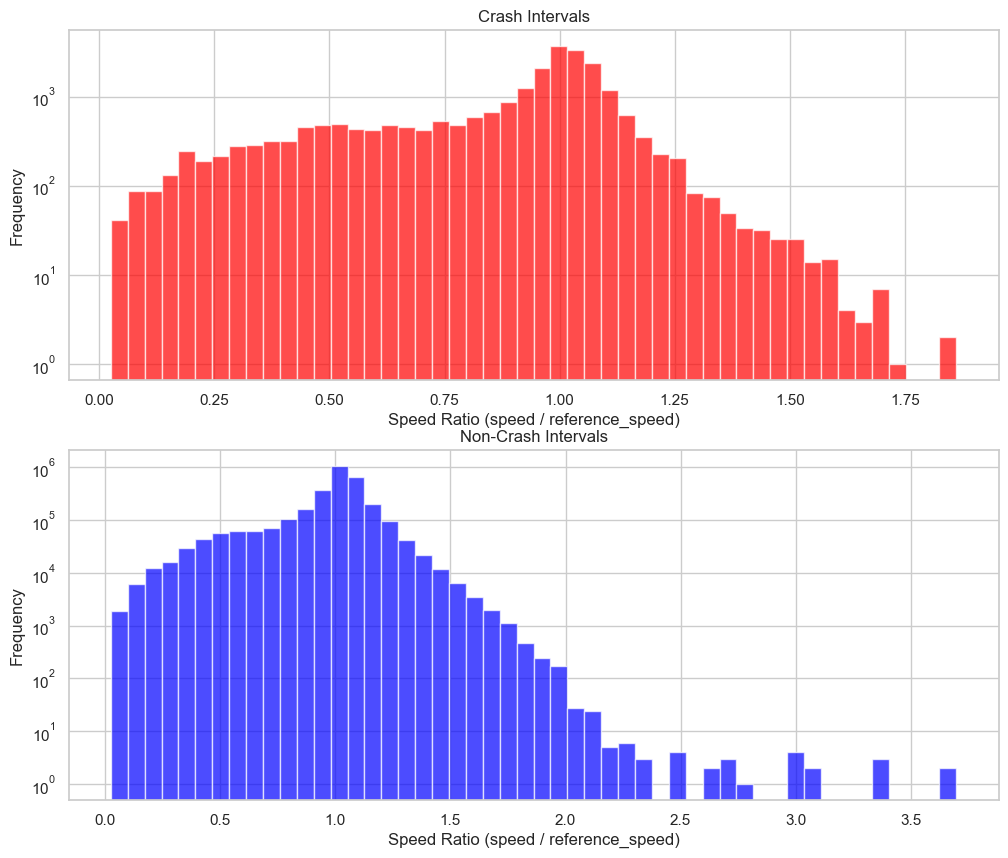

In [389]:
plt.figure(figsize=(12, 10))

plt.subplot(2, 1, 1)
plt.hist(
    high_crash_speeds[high_crash_speeds['is_crash'] == True]['speed_ratio'],
    bins=50, color='red', alpha=0.7
)
plt.title('Crash Intervals')
plt.xlabel('Speed Ratio (speed / reference_speed)')
plt.ylabel('Frequency')
plt.yscale('log')

plt.subplot(2, 1, 2)
plt.hist(
    high_crash_speeds[high_crash_speeds['is_crash'] == False]['speed_ratio'],
    bins=50, color='blue', alpha=0.7
)
plt.title('Non-Crash Intervals')
plt.xlabel('Speed Ratio (speed / reference_speed)')
plt.ylabel('Frequency')
plt.yscale('log')
plt.show()

In [390]:
start_et = pd.Timestamp("2019-01-12 23:13:00-05:00")
end_et = pd.Timestamp("2019-01-13 00:05:51-05:00")

start_utc = start_et.tz_convert('UTC')
end_utc = end_et.tz_convert('UTC')

print("Start Time (UTC):", start_utc)
print("End Time (UTC):", end_utc)

Start Time (UTC): 2019-01-13 04:13:00+00:00
End Time (UTC): 2019-01-13 05:05:51+00:00


In [391]:
intervals_utc = pd.date_range(start=start_utc.floor('5T'), end=end_utc.ceil('5T'), freq='5T')

print(intervals_utc)

DatetimeIndex(['2019-01-13 04:10:00+00:00', '2019-01-13 04:15:00+00:00',
               '2019-01-13 04:20:00+00:00', '2019-01-13 04:25:00+00:00',
               '2019-01-13 04:30:00+00:00', '2019-01-13 04:35:00+00:00',
               '2019-01-13 04:40:00+00:00', '2019-01-13 04:45:00+00:00',
               '2019-01-13 04:50:00+00:00', '2019-01-13 04:55:00+00:00',
               '2019-01-13 05:00:00+00:00', '2019-01-13 05:05:00+00:00',
               '2019-01-13 05:10:00+00:00'],
              dtype='datetime64[ns, UTC]', freq='5T')


In [392]:
segment_check = 'segment_2034'

sample_intervals = high_crash_speeds[
    (high_crash_speeds['segment_id'] == segment_check) &
    (high_crash_speeds['measurement_tstamp'].isin(intervals_utc))
]

print(sample_intervals[['measurement_tstamp', 'is_crash']])

              measurement_tstamp  is_crash
97602  2019-01-13 04:10:00+00:00      True
97603  2019-01-13 04:10:00+00:00      True
97604  2019-01-13 04:10:00+00:00      True
97605  2019-01-13 04:15:00+00:00      True
97606  2019-01-13 04:15:00+00:00      True
97607  2019-01-13 04:15:00+00:00      True
97608  2019-01-13 04:20:00+00:00      True
97609  2019-01-13 04:20:00+00:00      True
97610  2019-01-13 04:20:00+00:00      True
97611  2019-01-13 04:25:00+00:00      True
97612  2019-01-13 04:25:00+00:00      True
97613  2019-01-13 04:25:00+00:00      True
97614  2019-01-13 04:30:00+00:00      True
97615  2019-01-13 04:30:00+00:00      True
97616  2019-01-13 04:30:00+00:00      True
97617  2019-01-13 04:35:00+00:00      True
97618  2019-01-13 04:35:00+00:00      True
97619  2019-01-13 04:35:00+00:00      True
97620  2019-01-13 04:40:00+00:00      True
97621  2019-01-13 04:40:00+00:00      True
97622  2019-01-13 04:40:00+00:00      True
97623  2019-01-13 04:45:00+00:00      True
97624  2019